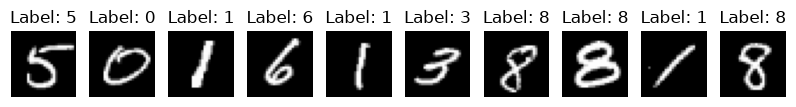

Pixel values of the first image in the training set:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0  17  47  47  47  47  47  47  28   0]
 [  0   0   0   0   0   0   0   0   0  14  63   0   0   0  62 138 197 197
  197 217 253 253 253 253 253 253 230   0]
 [  0   0   0   0   0   0   0   0   0 151 170   0  56 232 250 253 231 217
  217 217 217 217 217 217 128 179 132   0]
 [  0   0  

In [ ]:


from torchvision.datasets import MNIST
from sklearn.model_selection import train_test_split

# Load the MNIST dataset
mnist = MNIST(
    root='./data', download=True
)
# transform the dataset to tensors and normalize the pixel values to [0, 1]
X, y = mnist.data.numpy(), mnist.targets.numpy()
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# plot the first 10 images in the training set
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
plt.show()  

# print pixel values of the first image in the training set
print("Pixel values of the first image in the training set:")
print(X_train[0])

In [19]:
import torch.nn as nn
import torch

class neuralnetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  

        self.fc=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x=self.conv(x)
        x=self.fc(x)
        return x    
     
model=neuralnetwork()


In [27]:
import torch.nn as nn
import torch
import torch.optim as optim

epochs=10
batch_size=64
optimizer=torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        
        # Convert to torch tensors
        X_batch = torch.tensor(X_batch, dtype=torch.float32).unsqueeze(1) / 255.0  # Normalize and add channel dimension
        y_batch = torch.tensor(y_batch, dtype=torch.long)
        
        # Forward pass
        outputs = model(X_batch)
        
        # Compute loss
        loss = nn.functional.cross_entropy(outputs, y_batch)
        
        # Backward pass and optimization
        model.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [1/10], Loss: 0.0545
Epoch [2/10], Loss: 0.0120
Epoch [3/10], Loss: 0.0100
Epoch [4/10], Loss: 0.0013
Epoch [5/10], Loss: 0.0017
Epoch [6/10], Loss: 0.0006
Epoch [7/10], Loss: 0.0052
Epoch [8/10], Loss: 0.0007
Epoch [9/10], Loss: 0.0004
Epoch [10/10], Loss: 0.0000


In [29]:
# Evaluate the model on the test set
# add the predicted labels to the test set and plot the first 10 images in the test set with their predicted labels and true labels
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1) / 255.0  # Normalize and add channel dimension
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)   

# plot the first 10 images in the test set with their predicted labels and true labels
plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f'True: {y_test[i]}\nPred: {predicted[i].item()}')
    plt.axis('off') 
    

RuntimeError: [enforce fail at alloc_cpu.cpp:117] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1204224000 bytes.